In [1]:
# gw-neutral-main.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/base/gw-neutral/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/base/gw-neutral/stats"
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/base/gw-neutral/figures"

In [5]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from urdr import *

In [6]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [9]:
tool_labels = ['seed_N', 'stCNASim-cs_N', 'scDesign2-cna_N', 'stCNASim-cs_T', 'scDesign2-cna_T']
tool_palette = {
    'seed_N': orange,
    'stCNASim-cs_N': '#56B4E9',
    'scDesign2-cna_N': green,
    'stCNASim-cs_T': '#F0E442',
    'scDesign2-cna_T': blue
}

# Load Data

In [10]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
cs_normal_fn = os.path.join(in_dir, "cs_normal.h5ad")
cs_tumor_fn = os.path.join(in_dir, "cs_tumor.h5ad")
ind_normal_fn = os.path.join(in_dir, "ind_normal.h5ad")
ind_tumor_fn = os.path.join(in_dir, "ind_tumor.h5ad")

In [11]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

cs_normal = ad.read_h5ad(cs_normal_fn)
print(cs_normal)

cs_tumor = ad.read_h5ad(cs_tumor_fn)
print(cs_tumor)

ind_normal = ad.read_h5ad(ind_normal_fn)
print(ind_normal)

ind_tumor = ad.read_h5ad(ind_tumor_fn)
print(ind_tumor)

AnnData object with n_obs × n_vars = 600 × 27317
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27317
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27317
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27317
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'region', 'cn0', 'cn1', 'cna_type', 'feature'
AnnData object with n_obs × n_vars = 600 × 27317
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'region', 'cn0', 'cn1', 'cna_type', 'feature'


# Cell-wise Metrics

In [12]:
mv = get_cw_metrics_group(
    X_lst = [seed_normal.X, cs_normal.X, ind_normal.X, cs_tumor.X, ind_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.obs['cell'].to_numpy(), cs_normal.obs['cell'].to_numpy(), ind_normal.obs['cell'].to_numpy(),
             cs_tumor.obs['cell'].to_numpy(), ind_tumor.obs['cell'].to_numpy()],
    metrics = ["lib_size", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,lib_size,zero_prop,group,cell
0,7863.0,0.908702,seed_N,AAACAAGTATCTCCCA-1
1,15142.0,0.862430,seed_N,AAACATTTCCCGGATT-1
2,9618.0,0.897646,seed_N,AAACCGTTCGTCCAGG-1
3,11831.0,0.886664,seed_N,AAACCTAAGCAGCCGG-1
4,4901.0,0.932972,seed_N,AAACGGGCGTACGGGT-1
...,...,...,...,...
2995,7368.0,0.915913,scDesign2-cna_T,TTTACACGGACTGCTC-1
2996,7171.0,0.916755,scDesign2-cna_T,TTTACCGGGAATATAT-1
2997,7331.0,0.918293,scDesign2-cna_T,TTTCCACCTAATCATT-1
2998,7309.0,0.914046,scDesign2-cna_T,TTTTCGCTTCTGAATT-1


In [13]:
tmp = mv[["group", "cell", "lib_size", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_stat_dir, cw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

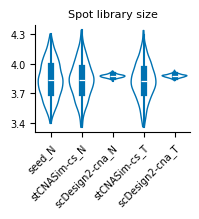

In [14]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['lib_size']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
#ax.set_ylim(3.35, 4.5)
#ax.set_yticks([3.4, 3.6, 3.8, 4.0, 4.2])
ax.set_yticks([3.4, 3.7, 4.0, 4.3])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Spot library size", fontsize = 8)
plt.tight_layout()
fn = os.path.join(out_fig_dir, cw_prefix + "libsize.png")
fig.savefig(fn, dpi = 300)

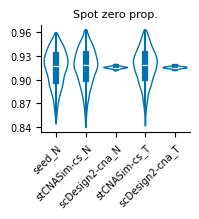

In [15]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0.84, 0.87, 0.9, 0.93, 0.96])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Spot zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, cw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300)

# Gene-wise Metrics

In [16]:
mv = get_gw_metrics_group(
    X_lst = [seed_normal.X, cs_normal.X, ind_normal.X, cs_tumor.X, ind_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), cs_normal.var['feature'].to_numpy(), ind_normal.var['feature'].to_numpy(),
             cs_tumor.var['feature'].to_numpy(), ind_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.000000,0.000000,0.000000,1.000000,seed_N,MIR1302-2HG
1,0.000000,0.000000,0.000000,1.000000,seed_N,FAM138A
2,0.000000,0.000000,0.000000,1.000000,seed_N,OR4F5
3,0.001667,0.001664,24.474475,0.998333,seed_N,AL627309.1
4,0.000000,0.000000,0.000000,1.000000,seed_N,AL627309.3
...,...,...,...,...,...,...
136580,0.078333,0.075531,3.508452,0.923333,scDesign2-cna_T,ARRDC1-AS1
136581,0.243333,0.240789,2.016584,0.783333,scDesign2-cna_T,EHMT1
136582,0.000000,0.000000,0.000000,1.000000,scDesign2-cna_T,AL772363.1
136583,0.000000,0.000000,0.000000,1.000000,scDesign2-cna_T,CACNA1B


In [17]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [18]:
np.log10(mv['mean'].min() + 1), np.log10(mv['mean'].max() + 1)

(0.0, 2.409451239285247)

## Single Metric

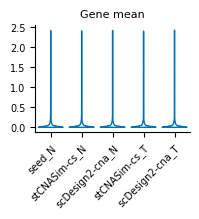

In [19]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['mean']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "mean.png")
fig.savefig(fn, dpi = 300)

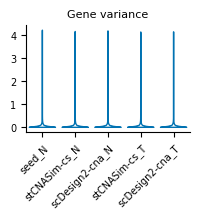

In [20]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['var']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene variance", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "variance.png")
fig.savefig(fn, dpi = 300)

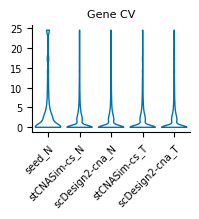

In [21]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['cv']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene CV", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "cv.png")
fig.savefig(fn, dpi = 300)

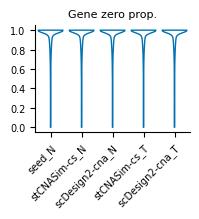

In [22]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [23]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "perc-of-genes-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

              group  level_1  cutoff        label    percent
0            seed_N        0    0.90     [0, 0.9)  22.696489
1            seed_N        1    0.99  [0.9, 0.99)  17.589779
2            seed_N        2    1.01    [0.99, 1]  59.713731
3     stCNASim-cs_N        0    0.90     [0, 0.9)  22.590328
4     stCNASim-cs_N        1    0.99  [0.9, 0.99)  17.589779
5     stCNASim-cs_N        2    1.01    [0.99, 1]  59.819892
6   scDesign2-cna_N        0    0.90     [0, 0.9)  22.685507
7   scDesign2-cna_N        1    0.99  [0.9, 0.99)  17.575136
8   scDesign2-cna_N        2    1.01    [0.99, 1]  59.739356
9     stCNASim-cs_T        0    0.90     [0, 0.9)  22.403631
10    stCNASim-cs_T        1    0.99  [0.9, 0.99)  17.725226
11    stCNASim-cs_T        2    1.01    [0.99, 1]  59.871143
12  scDesign2-cna_T        0    0.90     [0, 0.9)  22.678186
13  scDesign2-cna_T        1    0.99  [0.9, 0.99)  17.633708
14  scDesign2-cna_T        2    1.01    [0.99, 1]  59.688106


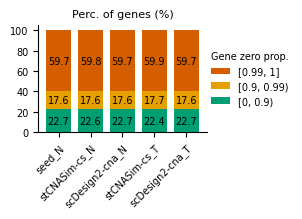

In [24]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 0
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (3.1, 2.3))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "Gene zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of genes (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "perc-of-genes-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

## Pair of Metrics

In [25]:
st_smooth = stat_smooth(
    x = "mean",
    y = "zero_prop",
    data = mv, 
    k = 100,
    group = "group",
    log_scale = (True, False),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "zero_prop-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'seed_N' ...
processing group 'stCNASim-cs_N' ...
processing group 'scDesign2-cna_N' ...
processing group 'stCNASim-cs_T' ...
processing group 'scDesign2-cna_T' ...
                  group      mean  zero_prop
0                seed_N  0.000000   1.000000
1                seed_N  0.000000   1.000000
2                seed_N  0.000000   1.000000
3                seed_N  0.000000   1.000000
4                seed_N  0.000000   1.000000
...                 ...       ...        ...
136580  scDesign2-cna_T  2.218680   0.000098
136581  scDesign2-cna_T  2.320143   0.000052
136582  scDesign2-cna_T  2.334387   0.000048
136583  scDesign2-cna_T  2.351767   0.000043
136584  scDesign2-cna_T  2.409451   0.000029

[136585 rows x 3 columns]


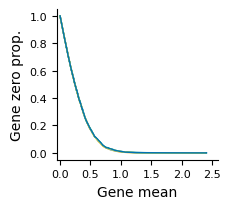

In [26]:
fig = plt.figure(figsize = (2.4, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "zero_prop", hue = 'group', 
    legend = False,
    linewidth = 1,
    palette = tool_palette
)
ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 8
)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 8
)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-0.05, 2.6)
ax.set_xlabel(r"Gene mean")
ax.set_ylabel("Gene zero prop.")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "zero_prop-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [27]:
st_smooth = stat_smooth(
    x = "mean",
    y = "var",
    data = mv,
    k = 100,
    group = "group",
    log_scale = (True, True),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "var-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'seed_N' ...
processing group 'stCNASim-cs_N' ...
processing group 'scDesign2-cna_N' ...
processing group 'stCNASim-cs_T' ...
processing group 'scDesign2-cna_T' ...
                  group      mean       var
0                seed_N  0.000000  0.000000
1                seed_N  0.000000  0.000000
2                seed_N  0.000000  0.000000
3                seed_N  0.000000  0.000000
4                seed_N  0.000000  0.000000
...                 ...       ...       ...
136580  scDesign2-cna_T  2.218680  3.250542
136581  scDesign2-cna_T  2.320143  3.423634
136582  scDesign2-cna_T  2.334387  3.445507
136583  scDesign2-cna_T  2.351767  3.471350
136584  scDesign2-cna_T  2.409451  3.550440

[136585 rows x 3 columns]


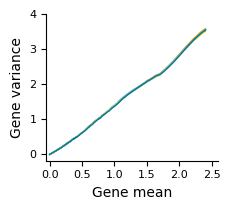

In [28]:
fig = plt.figure(figsize = (2.4, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "var", hue = 'group', 
    legend = False,
    linewidth = 1,
    palette = tool_palette
)
ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 8
)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 8
)
ax.set_xlim(-0.05, 2.6)
ax.set_xlabel(r"Gene mean")
ax.set_ylabel(r"Gene variance")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "var-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [29]:
mv2 = mv[~((mv["mean"] <= 0) & (mv["cv"] <= 0))].copy()

st_smooth = stat_smooth(
    x = "mean",
    y = "cv",
    data = mv2, 
    k = 100,
    group = "group",
    log_scale = (True, False),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "cv-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'seed_N' ...
processing group 'stCNASim-cs_N' ...
processing group 'scDesign2-cna_N' ...
processing group 'stCNASim-cs_T' ...
processing group 'scDesign2-cna_T' ...
                 group      mean         cv
0               seed_N  0.000723  24.474475
1               seed_N  0.000723  24.474475
2               seed_N  0.000723  24.474475
3               seed_N  0.000723  24.474475
4               seed_N  0.000723  24.474475
...                ...       ...        ...
64549  scDesign2-cna_T  2.218680   0.473261
64550  scDesign2-cna_T  2.320143   0.472020
64551  scDesign2-cna_T  2.334387   0.471936
64552  scDesign2-cna_T  2.351767   0.471856
64553  scDesign2-cna_T  2.409451   0.471751

[64554 rows x 3 columns]


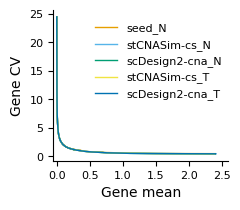

In [30]:
fig = plt.figure(figsize = (2.5, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "cv", hue = 'group',
    linewidth = 1,
    palette = tool_palette
)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles = handles, labels = tool_labels)
sns.move_legend(
    ax, "upper left", title = None, frameon = False,
    bbox_to_anchor = (0.18, 0.98), fontsize = 8
)
ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 8
)
ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 8
)
ax.set_xlim(-0.05, 2.6)
ax.set_xlabel(r"Gene mean")
ax.set_ylabel("Gene CV")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "cv-vs-mean.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [31]:
pairs = [
    ("stCNASim-cs_N", "seed_N"),
    ("scDesign2-cna_N", "seed_N"),
    ("stCNASim-cs_N", "scDesign2-cna_N"),
    ("stCNASim-cs_T", "scDesign2-cna_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [32]:
st_lr = stat_LR(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "mean-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2  p_value
0           seed_N    stCNASim-cs_N  0.997441 -0.000174  0.999077      0.0
1           seed_N  scDesign2-cna_N  0.999642 -0.000095  0.999013      0.0
2  scDesign2-cna_N    stCNASim-cs_N  0.996838 -0.000034  0.998140      0.0
3  scDesign2-cna_T    stCNASim-cs_T  0.987591 -0.000210  0.998042      0.0


In [33]:
df_mean = long2wide(mv, columns = 'group', values = 'mean', index = 'feature')
print(df_mean)

tmp = df_mean.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "mean-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group          seed_N  stCNASim-cs_N  scDesign2-cna_N  stCNASim-cs_T  \
feature                                                                
MIR1302-2HG  0.000000       0.000000         0.000000       0.000000   
FAM138A      0.000000       0.000000         0.000000       0.000000   
OR4F5        0.000000       0.000000         0.000000       0.000000   
AL627309.1   0.001667       0.000000         0.000000       0.000000   
AL627309.3   0.000000       0.000000         0.000000       0.000000   
...               ...            ...              ...            ...   
ARRDC1-AS1   0.078333       0.070000         0.071667       0.083333   
EHMT1        0.233333       0.208333         0.248333       0.235000   
AL772363.1   0.000000       0.000000         0.000000       0.000000   
CACNA1B      0.001667       0.000000         0.000000       0.000000   
AL954642.1   0.000000       0.000000         0.000000       0.000000   

group        scDesign2-cna_T  
feature                       
M

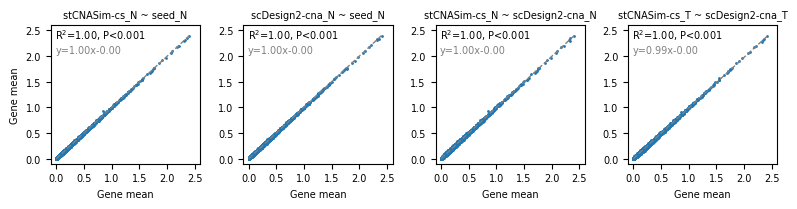

In [34]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_mean.columns)
df = df_mean[columns].copy()
df = df.map(lambda x: np.log10(x + 1))

gvars = st_lr[['x', 'y']].copy()
x_min, x_max = None, None
cols = np.union1d(gvars['x'], gvars['y'])
for c in cols:
    if x_min is None:
        x_min = df[c].min()
    elif df[c].min() < x_min:
        x_min = df[c].min()
    if x_max is None:
        x_max = df[c].max()
    elif df[c].max() > x_max:
        x_max = df[c].max()
xlims = (x_min, x_max)
    
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene mean", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlim(-0.1, 2.6)
    ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_ylim(-0.1, 2.6)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "mean-lr.png")
fig.savefig(fn, dpi = 300)

### Log2FC vs. Mean

In [35]:
pairs = [
    ("stCNASim-cs_T", "stCNASim-cs_N"),
    ("scDesign2-cna_T", "scDesign2-cna_N")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [36]:
st_log2fc = stat_log2fc(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars
)
print(st_log2fc)


tmp = st_log2fc.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "log2fc-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                     x                y    mean_x    mean_y    log2FC
0        stCNASim-cs_N    stCNASim-cs_T  0.000000  0.000000  0.000000
1        stCNASim-cs_N    stCNASim-cs_T  0.000000  0.000000  0.000000
2        stCNASim-cs_N    stCNASim-cs_T  0.000000  0.000000  0.000000
3        stCNASim-cs_N    stCNASim-cs_T  0.000000  0.000000  0.000000
4        stCNASim-cs_N    stCNASim-cs_T  0.000000  0.000000  0.000000
...                ...              ...       ...       ...       ...
54629  scDesign2-cna_N  scDesign2-cna_T  0.071667  0.078333  0.128324
54630  scDesign2-cna_N  scDesign2-cna_T  0.248333  0.243333 -0.029344
54631  scDesign2-cna_N  scDesign2-cna_T  0.000000  0.000000  0.000000
54632  scDesign2-cna_N  scDesign2-cna_T  0.000000  0.000000  0.000000
54633  scDesign2-cna_N  scDesign2-cna_T  0.000000  0.000000  0.000000

[54634 rows x 5 columns]


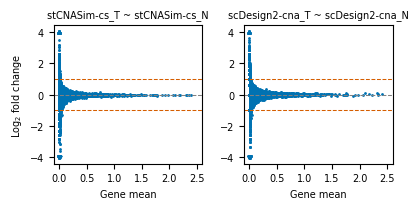

In [37]:
ncols = 2
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (4.15, 2.2))

cut = (-4, 4)
cut_markers = ('v', '^')
fontsize = 7

gvars = selected_gvars.copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs[k]
    cx = gvars['x'].iloc[i]
    cy = gvars['y'].iloc[i]
    df = st_log2fc.loc[(st_log2fc['x'] == cx) & (st_log2fc['y'] == cy)].copy()

    vx = df['mean_x'].to_numpy()
    vy = df['log2FC'].to_numpy()
    vx = np.log10(vx + 1)

    low, high = cut
    x1 = vx[vy > high]
    y1 = np.repeat(high, len(x1))
    x2 = vx[np.logical_and(vy >= low, vy <= high)]
    y2 = vy[np.logical_and(vy >= low, vy <= high)]
    x3 = vx[vy < low]
    y3 = np.repeat(low, len(x3))
    
    ax.plot(x1, y1, marker = cut_markers[1], markersize = 2, 
            linestyle = 'none', color = def_color)
    ax.plot(x2, y2, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)
    ax.plot(x3, y3, marker = cut_markers[0], markersize = 2, 
            linestyle = 'none', color = def_color)

    fc_kws = dict()
    ax.axhline(
        y = fc_kws.get('y_up', 1),
        linestyle = fc_kws.get('linestyle', '--'),
        linewidth = fc_kws.get('linewidth', 0.75),
        color = fc_kws.get('color', red)
    )
    ax.axhline(
        y = fc_kws.get('y_low', -1),
        linestyle = fc_kws.get('linestyle', '--'),
        linewidth = fc_kws.get('linewidth', 0.75),
        color = fc_kws.get('color', red)
    )

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlim(-0.1, 2.6)
    ax.set_ylim(-4.4, 4.4)
    ax.set_yticks([-4, -2, 0, 2, 4])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("Gene mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel(r"Log$_2$ fold change", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "log2fc-vs-mean.png")
fig.savefig(fn, dpi = 300)